# Check RMSE and ACC for Factual Simulations
Determine if 10 ensemble members is sufficient

Import statments

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

## Process data

Load data

In [2]:
start = 2004
stop = 2023
nens = 20

years = np.arange(start,stop+1,1)
ens_list = np.arange(1,nens+1,1)

files = [
    [
        f"/glade/work/smhenry/NeuralGCM/data/tracks/factual/ens{ens}_{year}_JASO_TC_tracks_factual.txt"
        for ens in range(1, nens + 1)
    ]
    for year in range(start, stop + 1)
]

Counting function (from manuscript_figure1.ipynb)

In [3]:
def count_NA(file):
    """
    counts the number of TCs from TempestExtremes output in the North Atlantic Basin
    input: file, a file name which is an output from TempestExtremes
    output: count, the number of TCs tracked in the file
    """
    count = 0
    in_TC = False
    is_in_NA = False

    with open(file, "r") as df:
        for line in df:
            if line.startswith("start"):
                if is_in_NA:
                    count += 1
                is_in_NA = False
                in_TC = True
            elif in_TC:
                data = line.split()
                if len(data) >= 4:
                    lon = float(data[2])
                    lat = float(data[3])

                    if (
                        (285 <= lon <= 360 and 0 <= lat <= 50)
                        or (276 <= lon < 285 and 10 <= lat <= 50)
                        or (262 <= lon < 276 and 16.5 <= lat <= 50)
                    ):
                        is_in_NA = True

        if is_in_NA:
            count += 1

    return count


def count_global(file):
    """
    counts the number of TCs from TempestExtremes output globally
    input: file, a file name which is an output from TempestExtremes
    output: count, the number of TCs tracked in the file
    """
    count = 0
    in_TC = False

    with open(file, "r") as df:
        for line in df:
            if line.startswith("start"):
                count += 1
                in_TC = True
            elif in_TC:
                data = line.split()
                if len(data) >= 4:
                    lon = float(data[2])
                    lat = float(data[3])

        count += 1

    return count

Create DataArray with counts

In [4]:
counts_array = np.zeros((nens, stop-start+1))
for iyr, files_year in enumerate(files):
    for iens, file in enumerate(files_year):
        count = count_global(file)  # consider also checking the NA counts
        counts_array[iyr][iens] = count

counts = xr.DataArray(
    data=counts_array,
    coords={"year": years, "ens": ens_list},
    dims=["year", "ens"]
)

Simulation function

In [5]:
def get_var_rmse_acc(dataarray, n_random, n_iterations):
    def compute_rmse(pred, truth):
        rmse = np.sqrt(
            ((pred - truth) ** 2).mean()
        )
        return rmse

    def compute_acc(pred, truth):
        pred_anom = pred - pred.mean(dim="year")
        truth_anom = truth - truth.mean(dim="year")

        numerator = (pred_anom * truth_anom).mean()
        denominator = np.sqrt(
            (pred_anom**2).mean()
            * (truth_anom**2).mean()
        )

        acc = numerator / denominator
        return acc

    rmse_list = []
    acc_list = []

    full_ens_mean = dataarray.mean(dim="ens")
    full_ens_mean

    for i in range(n_iterations):
        if i % 100 == 0:
            print("iteration:", i)
        random_ens = np.random.choice(
            dataarray.ens.values, size=n_random, replace=False
        )
        data_subset = dataarray.sel(ens=random_ens)

        ens_mean = data_subset.mean(dim="ens")

        rmse_list.append(compute_rmse(ens_mean, full_ens_mean))
        acc_list.append(compute_acc(ens_mean, full_ens_mean))

    rmse = xr.concat(rmse_list, dim="iteration")
    acc = xr.concat(acc_list, dim="iteration")

    return rmse, acc


rmse_05, acc_05 = get_var_rmse_acc(counts, 5, 1000)
rmse_10, acc_10 = get_var_rmse_acc(counts, 10, 1000)
rmse_15, acc_15 = get_var_rmse_acc(counts, 15, 1000)

iteration: 0
iteration: 100
iteration: 200
iteration: 300
iteration: 400
iteration: 500
iteration: 600
iteration: 700
iteration: 800
iteration: 900
iteration: 0
iteration: 100
iteration: 200
iteration: 300
iteration: 400
iteration: 500
iteration: 600
iteration: 700
iteration: 800
iteration: 900
iteration: 0
iteration: 100
iteration: 200
iteration: 300
iteration: 400
iteration: 500
iteration: 600
iteration: 700
iteration: 800
iteration: 900


## Plot ACC and RMSE

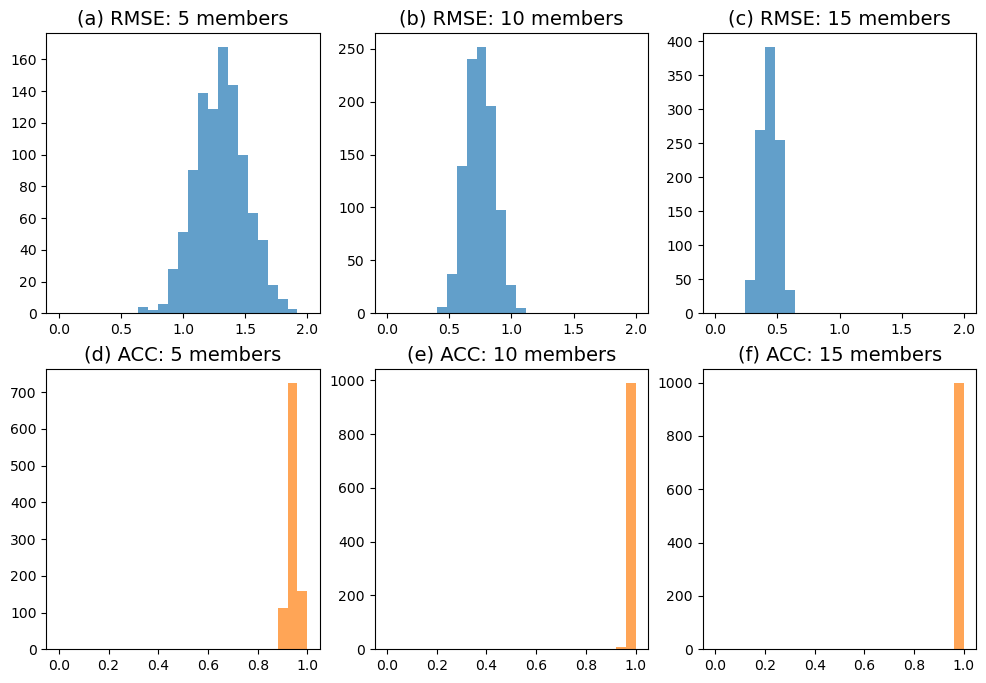

In [6]:
fig, axes = plt.subplots(nrows=2, ncols=3,figsize=(12,8))
axes = axes.flatten()

subtitle_list = ["(a) RMSE: 5 members", "(b) RMSE: 10 members", "(c) RMSE: 15 members", "(d) ACC: 5 members", "(e) ACC: 10 members", "(f) ACC: 15 members",]

rmse_05.plot.hist(bins=25, alpha=0.7, color="tab:blue", ax=axes[0], range=(0,2))
rmse_10.plot.hist(bins=25, alpha=0.7, color="tab:blue", ax=axes[1], range=(0,2))
rmse_15.plot.hist(bins=25, alpha=0.7, color="tab:blue", ax=axes[2], range=(0,2))

acc_05.plot.hist(bins=25, alpha=0.7, color="tab:orange", ax=axes[3], range=(0,1))
acc_10.plot.hist(bins=25, alpha=0.7, color="tab:orange", ax=axes[4], range=(0,1))
acc_15.plot.hist(bins=25, alpha=0.7, color="tab:orange", ax=axes[5], range=(0,1))

for i in range(len(axes)):
    axes[i].set_title(subtitle_list[i],fontsize=14)

plt.savefig("./figs/SI_figure3.png",bbox_inches="tight",dpi=600)

plt.show()